In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier as SkKNN
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.linear_model import LogisticRegression as SkLogisticRegression

from cclassify.knn import KNNClassifier
from cclassify.naive_bayes import GaussianNB
from cclassify.logistic import LogisticRegressionBinary

In [3]:
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2100, 20)
X_test shape: (900, 20)


In [4]:
def benchmark_model(model_factory, X_train, y_train, X_test, y_test, n_runs=5):
    fit_times = []
    predict_times = []
    accuracies = []

    for _ in range(n_runs):
        model = model_factory()

        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        fit_times.append(time.perf_counter() - t0)

        t1 = time.perf_counter()
        y_pred = model.predict(X_test)
        predict_times.append(time.perf_counter() - t1)

        accuracies.append(accuracy_score(y_test, y_pred))

    return {
        "fit_time_mean": np.mean(fit_times),
        "fit_time_std": np.std(fit_times),
        "predict_time_mean": np.mean(predict_times),
        "predict_time_std": np.std(predict_times),
        "accuracy_mean": np.mean(accuracies),
        "accuracy_std": np.std(accuracies),
    }

In [5]:
benchmarks = {
    "cclassify KNN": lambda: KNNClassifier(k=3),
    "sklearn KNN": lambda: SkKNN(n_neighbors=3),

    "cclassify GaussianNB": lambda: GaussianNB(),
    "sklearn GaussianNB": lambda: SkGaussianNB(),

    "cclassify LogisticRegressionBinary": lambda: LogisticRegressionBinary(
        learning_rate=0.1,
        n_iter=2000,
        threshold=0.5
    ),
    "sklearn LogisticRegression": lambda: SkLogisticRegression(
        max_iter=2000
    ),
}

In [9]:
results = []

for name, factory in benchmarks.items():
    stats = benchmark_model(factory, X_train, y_train, X_test, y_test, n_runs=30)
    row = {"model": name}
    row.update(stats)
    results.append(row)

df = pd.DataFrame(results)
df

,model,fit_time_mean,fit_time_std,predict_time_mean,predict_time_std,accuracy_mean,accuracy_std
0,cclassify KNN,0.000032,0.000112,0.052970,0.022461,0.928889,1.110223e-16
1,sklearn KNN,0.001530,0.000656,0.014295,0.004241,0.928889,1.110223e-16
2,cclassify GaussianNB,0.000285,0.000101,0.000632,0.000130,0.855556,2.220446e-16
3,sklearn GaussianNB,0.003918,0.001266,0.001038,0.000260,0.855556,2.220446e-16
4,cclassify LogisticRegressionBinary,0.360821,0.092243,0.000103,0.000042,0.815556,1.110223e-16
5,sklearn LogisticRegression,0.042888,0.019526,0.001464,0.001049,0.815556,1.110223e-16


In [10]:
df_sorted = df.sort_values("model").reset_index(drop=True)
df_sorted

,model,fit_time_mean,fit_time_std,predict_time_mean,predict_time_std,accuracy_mean,accuracy_std
0,cclassify GaussianNB,0.000285,0.000101,0.000632,0.000130,0.855556,2.220446e-16
1,cclassify KNN,0.000032,0.000112,0.052970,0.022461,0.928889,1.110223e-16
2,cclassify LogisticRegressionBinary,0.360821,0.092243,0.000103,0.000042,0.815556,1.110223e-16
3,sklearn GaussianNB,0.003918,0.001266,0.001038,0.000260,0.855556,2.220446e-16
4,sklearn KNN,0.001530,0.000656,0.014295,0.004241,0.928889,1.110223e-16
5,sklearn LogisticRegression,0.042888,0.019526,0.001464,0.001049,0.815556,1.110223e-16


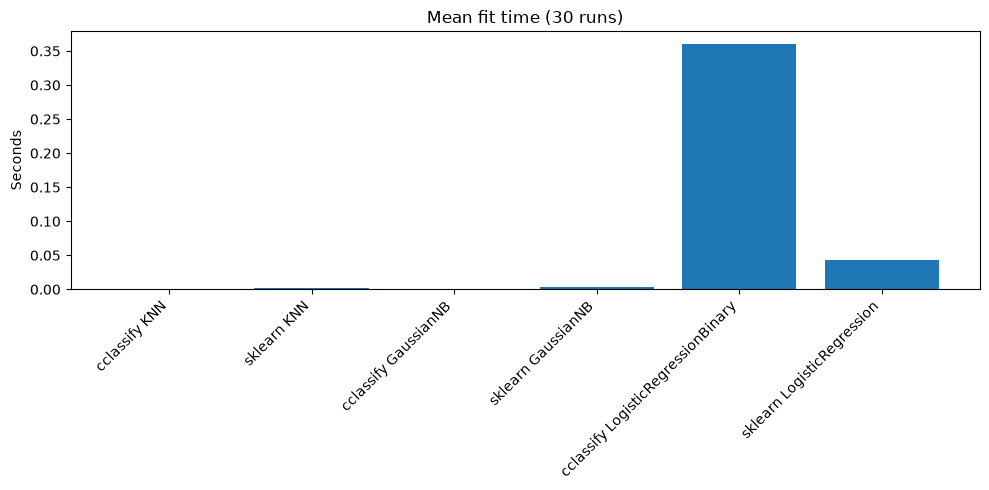

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(df["model"], df["fit_time_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Seconds")
plt.title("Mean fit time (30 runs)")
plt.tight_layout()
plt.show()

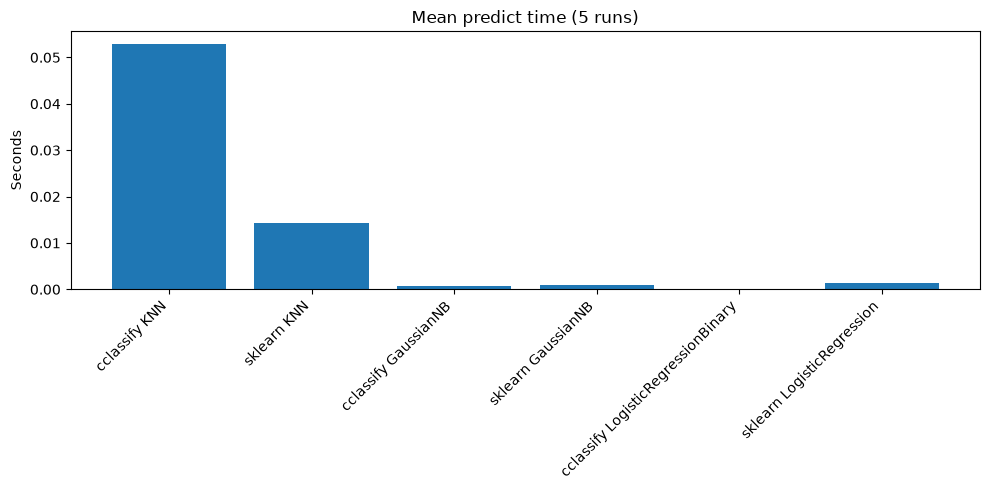

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(df["model"], df["predict_time_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Seconds")
plt.title("Mean predict time (5 runs)")
plt.tight_layout()
plt.show()